## Parte 2: Preprocesamiento de Datos

1. Transformación de Columnas:
* Utilizar ColumnTransformer para aplicar transformaciones específicas a diferentes columnas.
* Realizar codificación de variables categóricas y escalado de variables numéricas.
2. Pipelines:
* Crear pipelines para automatizar el preprocesamiento de datos y asegurar la reproducibilidad.

In [ ]:
# Importar librerias
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

In [ ]:
df1 = df.copy()

In [ ]:
# Elimino las columnas ID porque no me interesan
df1=df1.drop(columns=['Customer ID', 'Transaction ID', 'Date'])

In [ ]:
X = df1.drop(columns=['Total Amount']) # El resto Exepto variable objetivo

In [ ]:
y = df1['Total Amount'] # Variable objetivo

In [ ]:
from sklearn.model_selection import train_test_split

#  Dividir en train/test correctamente
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,          # 20% para test, 80% para train
    random_state=42,         # ← MUY IMPORTANTE: fija la aleatoriedad para que el resultado sea reproducible
    stratify=y
)

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')
print(f'y_train: {y_train.shape}, y_test: {y_test.shape}')
print(f'Suma OK: {len(X_train) + len(X_test) == len(X)}')

X_train: (800, 7), X_test: (200, 7)
y_train: (800,), y_test: (200,)
Suma OK: True


In [ ]:
# Prepocesado automatico
preprocesador = make_column_transformer(
    (MinMaxScaler(),  make_column_selector(dtype_include=np.number)),
    (OneHotEncoder(),   make_column_selector(dtype_include=object)),
    remainder='drop'
)
preprocesador

ColumnTransformer(transformers=[('minmaxscaler', MinMaxScaler(),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x7e7418533a40>),
                                ('onehotencoder', OneHotEncoder(),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x7e7441987560>)])

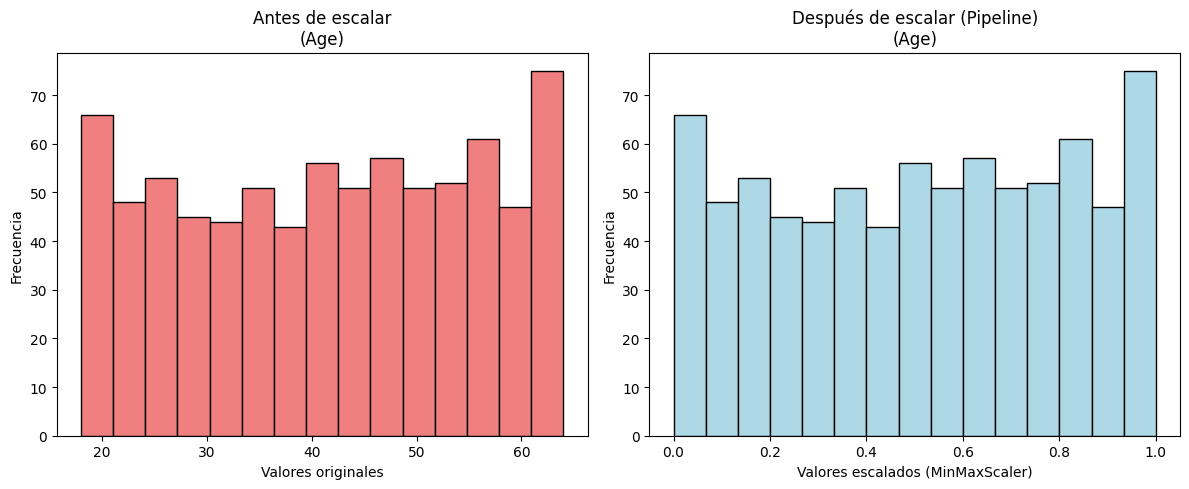

In [ ]:
# Visualización de los datos antes y despues de escalar
import matplotlib.pyplot as plt

col_name = X_train.columns[1]
X_train_esc = preprocesador.fit_transform(X_train)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Antes
axes[0].hist(X_train.iloc[:, 1], bins=15, color="lightcoral", edgecolor='black')
axes[0].set_title(f'Antes de escalar\n({col_name})')
axes[0].set_xlabel('Valores originales')
axes[0].set_ylabel('Frecuencia')

# Después
axes[1].hist(X_train_esc[:, 0], bins=15, color="lightblue", edgecolor='black') #
axes[1].set_title(f'Después de escalar (Pipeline)\n({col_name})')
axes[1].set_xlabel('Valores escalados (MinMaxScaler)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

In [ ]:

resultados = []
for nombre, pipe in modelos.items():
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    resultados.append({
        'Modelo': nombre,
        'R²':   r2_score(y_test, pred),
        'MAE':  mean_absolute_error(y_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred))
    })

print(pd.DataFrame(resultados).set_index('Modelo').round(2))

                     R²     MAE    RMSE
Modelo                                 
Lineal             0.85  175.45  214.20
Ridge              0.86  175.12  214.13
Lasso              0.86  175.33  214.02
KNN(k=10)          0.22  381.27  497.87
Árbol(d=10)        1.00    0.00    0.00
RandomForest(200)  1.00    0.00    0.00
GradientBoosting   1.00    0.00    0.00
